<a href="https://colab.research.google.com/github/olkanth/MSCS_634_ProjectDeliverable_3/blob/main/MSCS_634_Project_Deliverable3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laxmi Kanth Oruganti
## MSCS-634 : Advanced Big Data and Data Mining
## Project Deliverable 3 : Classification, Clustering, and Pattern Mining

**University:** University of the Cumberlands  
**Dataset:** Framingham Heart Study  
**Source:** [Kaggle – aasheesh200/framingham-heart-study-dataset](https://www.kaggle.com/datasets/aasheesh200/framingham-heart-study-dataset)


## 1. Introduction

In this deliverable, I am continuing from where I left off in Deliverables 1 and 2. I will be using the same Framingham Heart Study dataset which has 4,240 patient records and 16 features.

The main goal here is to predict whether a patient will develop coronary heart disease (CHD) in the next 10 years using classification models. I will also try to group patients into clusters based on their health measurements, and then use association rule mining to find interesting patterns in the data.

Here is what I plan to do in this deliverable:
- Build two classification models (Decision Tree and k-NN) to predict `TenYearCHD`
- Tune the Decision Tree using GridSearch to try to improve its performance
- Evaluate both models using confusion matrix, ROC curve, accuracy, and F1 score
- Apply K-Means clustering to group patients by their health profile
- Use the Apriori algorithm to find patterns between different health conditions
- Discuss what these findings could mean in a real-world context

**Target variable:** `TenYearCHD` — 0 means the patient did not develop CHD, 1 means they did

## 2. Library Imports

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# For splitting data and tuning models
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler

# Classification models
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier

# Evaluation metrics
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, f1_score,
    roc_curve, roc_auc_score, ConfusionMatrixDisplay
)

# Clustering
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Association rule mining
from mlxtend.frequent_patterns import apriori, association_rules

import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

# Create the directory if it doesn't exist
os.makedirs('Visualizations', exist_ok=True)

## 3. Load the Dataset

I load the same Framingham Heart Study dataset used in Deliverable 1 & 2. The CSV file is loaded from the local directory (uploaded via Colab).

In [34]:
# Upload dataset file (framingham.csv)
from google.colab import files

# uploaded = files.upload()
# uploaded

In [3]:
# -----------------------------------------------------------
# Load dataset and inspect
# Same dataset as Deliverable 1: 4,240 rows × 16 columns
# -----------------------------------------------------------
df = pd.read_csv('framingham.csv')
print(f"Dataset loaded successfully.")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print('=' * 50)
df.info()
print('=' * 50)
df.head()

Dataset loaded successfully.
Shape: 4,240 rows × 16 columns
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtype

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


## 4. Data Preprocessing (Replicated from deliverables 1 & 2)
I am reusing the same preprocessing steps from the previous deliverables to make sure the data is clean and consistent. This includes filling in missing values, capping outliers, and adding the engineered features I created in Deliverable 2.

This time, the target variable is `TenYearCHD` instead of `sysBP` (which I used for regression in Deliverable 2).

In [11]:
df_clean_data = df.copy()

# Missing columns — same lists as Deliverable 1 & 2
# Note: BPMeds is listed in both numeric_missing (for median fill)
# and non_numeric_missing (for mode fill) — mode fill overwrites
numeric_missing     = ["glucose", "BPMeds", "totChol", "BMI", "heartRate", "cigsPerDay"]
non_numeric_missing = ["education", "BPMeds"]

print("Missing values before imputation:")
missing_before = df_clean_data.isnull().sum()
print(missing_before[missing_before > 0])
print(f"Total: {df_clean_data.isnull().sum().sum()}")
print()

# Median imputation for numeric columns
for col in numeric_missing:
    median = df[col].median()
    df_clean_data[col].fillna(median, inplace=True)
    print(f"Imputed '{col}' with median value: {median}")

# Mode imputation for categorical/binary columns
for col in non_numeric_missing:
    mode = df[col].mode()[0]
    df_clean_data[col].fillna(mode, inplace=True)
    print(f"Imputed '{col}' with mode value: {mode}")

remaining = df_clean_data.isnull().sum().sum()
print("=" * 50)
print(f"Remaining missing values: {remaining}")
print()


# Duplicate Detection
duplicate_cnt = df_clean_data.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_cnt}")
if duplicate_cnt > 0:
    df_clean_data.drop_duplicates(inplace=True)
    print(f"Duplicates removed. New shape: {df_clean_data.shape}")
else:
    print("No duplicates found — no action needed.")
print()


# Outlier Detection & Treatment
# Two-step: IQR detection, then 1st-99th percentile Winsorization
continuous_cols   = ["totChol", "sysBP", "diaBP", "BMI", "glucose"]
discrete_num_cols = ["age", "cigsPerDay", "heartRate"]
all_numeric_cols  = continuous_cols + discrete_num_cols

print("STEP 1 — OUTLIER DETECTION (IQR Method)")
print("=" * 65)
outlier_report = {}
for col in all_numeric_cols:
    Q1  = df_clean_data[col].quantile(0.25)
    Q3  = df_clean_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df_clean_data[col] < lower) | (df_clean_data[col] > upper)).sum()
    pct   = n_out / len(df_clean_data) * 100
    outlier_report[col] = n_out
    print(f"  {col:<15} | IQR fence: [{lower:6.1f}, {upper:6.1f}] | Outliers: {n_out:>4} ({pct:.1f}%)")
print(f"\nTotal outlier instances detected: {sum(outlier_report.values()):,}")

print("\nSTEP 2 — OUTLIER TREATMENT (1st-99th Percentile Capping)")
print("=" * 65)
for col in all_numeric_cols:
    p01 = df_clean_data[col].quantile(0.01)
    p99 = df_clean_data[col].quantile(0.99)
    n_capped = ((df_clean_data[col] < p01) | (df_clean_data[col] > p99)).sum()
    df_clean_data[col] = df_clean_data[col].clip(lower=p01, upper=p99)
    print(f"  {col:<15} | P1={p01:>7.2f}  P99={p99:>7.2f} | Capped: {n_capped}")

print(f"\nPreprocessing complete. Working dataframe: df_clean_data")
print(f"Shape: {df_clean_data.shape}")
print()

# ------------------------------------------------------------------
# Feature Engineering
# Note: pulse_pressure is added here for classification use.
# It was NOT created in D2 (sysBP was the regression target there,
# so pulse_pressure = sysBP - diaBP would have been leakage).
# Here, TenYearCHD is the target, so pulse_pressure is a valid predictor.
# ------------------------------------------------------------------

# 1. Log-transformed glucose
df_clean_data['log_glucose'] = np.log1p(df_clean_data['glucose'])
print(f"1. log_glucose       — Mean: {df_clean_data['log_glucose'].mean():.4f}")

# 2. Log-transformed cigsPerDay
df_clean_data['log_cigsPerDay'] = np.log1p(df_clean_data['cigsPerDay'])
print(f"2. log_cigsPerDay    — Mean: {df_clean_data['log_cigsPerDay'].mean():.4f}")

# 3. Age squared
df_clean_data['age_squared'] = df_clean_data['age'] ** 2
print(f"3. age_squared       — Mean: {df_clean_data['age_squared'].mean():.2f}")

# 4. Hypertension Risk Score — min-max normalized
df_clean_data['hypertension_risk_score'] = (
    (df_clean_data['age']     - df_clean_data['age'].min()) /
    (df_clean_data['age'].max() - df_clean_data['age'].min()) +
    (df_clean_data['BMI']     - df_clean_data['BMI'].min()) /
    (df_clean_data['BMI'].max() - df_clean_data['BMI'].min()) +
    (df_clean_data['totChol'] - df_clean_data['totChol'].min()) /
    (df_clean_data['totChol'].max() - df_clean_data['totChol'].min()) +
    df_clean_data['diabetes'] +
    df_clean_data['prevalentHyp']
)
print(f"4. hypertension_risk_score — Mean: {df_clean_data['hypertension_risk_score'].mean():.2f}, "
      f"Range: [{df_clean_data['hypertension_risk_score'].min():.2f}, "
      f"{df_clean_data['hypertension_risk_score'].max():.2f}]")

# 5. Pulse pressure — valid here since sysBP is a predictor, not the target
# Systolic BP - Diastolic BP
df_clean_data['pulse_pressure'] = df_clean_data['sysBP'] - df_clean_data['diaBP']
print(f"5. pulse_pressure    — Mean: {df_clean_data['pulse_pressure'].mean():.2f}")

print(f"\nDataset shape after feature engineering: {df_clean_data.shape}")
print(f"Target variable distribution:")
print(df_clean_data['TenYearCHD'].value_counts())

Missing values before imputation:
education     105
cigsPerDay     29
BPMeds         53
totChol        50
BMI            19
heartRate       1
glucose       388
dtype: int64
Total: 645

Imputed 'glucose' with median value: 78.0
Imputed 'BPMeds' with median value: 0.0
Imputed 'totChol' with median value: 234.0
Imputed 'BMI' with median value: 25.4
Imputed 'heartRate' with median value: 75.0
Imputed 'cigsPerDay' with median value: 0.0
Imputed 'education' with mode value: 1.0
Imputed 'BPMeds' with mode value: 0.0
Remaining missing values: 0

Number of duplicate rows: 0
No duplicates found — no action needed.

STEP 1 — OUTLIER DETECTION (IQR Method)
  totChol         | IQR fence: [ 122.0,  346.0] | Outliers:   57 (1.3%)
  sysBP           | IQR fence: [  76.5,  184.5] | Outliers:  126 (3.0%)
  diaBP           | IQR fence: [  52.5,  112.5] | Outliers:   77 (1.8%)
  BMI             | IQR fence: [  15.6,   35.5] | Outliers:   97 (2.3%)
  glucose         | IQR fence: [  52.5,  104.5] | Outliers:

## 5. Classification

### 5.1 Setting Up Features and Splitting the Data

I am using `TenYearCHD` as the target variable. The features include the original columns plus the ones I engineered in Deliverable 2.

One thing I noticed is that the dataset is imbalanced — only about 15% of patients actually developed CHD. This means if the model just always predicted 'No CHD', it would still get ~85% accuracy without actually learning anything useful. To deal with this, I used `class_weight='balanced'` in the Decision Tree and I will also focus on F1 score as a better measure of performance.

In [26]:
feature_cols = [
    'male', 'age', 'currentSmoker', 'cigsPerDay', 'BPMeds',
    'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol',
    'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose',
    'log_glucose', 'log_cigsPerDay', 'age_squared',
    'pulse_pressure', 'hypertension_risk_score'
]

X = df_clean_data[feature_cols]
y = df_clean_data['TenYearCHD']

# 80/20 split, stratified to keep class proportions the same in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# y_train.value_counts()

# # # Scale the features
scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),      columns=feature_cols)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"\nClass balance (train) — No CHD: {(y_train==0).sum()}  CHD: {(y_train==1).sum()}")
print(f"Class balance (test)  — No CHD: {(y_test==0).sum()}   CHD: {(y_test==1).sum()}")

Training samples : 3392
Test samples     : 848

Class balance (train) — No CHD: 2877  CHD: 515
Class balance (test)  — No CHD: 719   CHD: 129


### 5.2 Model 1 — Decision Tree

I chose a Decision Tree because it is easy to understand and visualize. It works by asking a series of yes/no questions about the features to arrive at a prediction. I set `max_depth=5` as a starting point to prevent the tree from getting too complex.

In [28]:
# Train a baseline Decision Tree
dt_base = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    class_weight='balanced',
    random_state=42
)
dt_base.fit(X_train_sc, y_train)

y_pred_dt  = dt_base.predict(X_test_sc)
y_proba_dt = dt_base.predict_proba(X_test_sc)[:, 1]

acc_dt = accuracy_score(y_test, y_pred_dt)
f1_dt  = f1_score(y_test, y_pred_dt)
auc_dt = roc_auc_score(y_test, y_proba_dt)

print("=== Decision Tree (Baseline) ===")
print(f"Accuracy : {acc_dt:.4f}")
print(f"F1 Score : {f1_dt:.4f}")
print(f"ROC-AUC  : {auc_dt:.4f}")
print()
print(classification_report(y_test, y_pred_dt, target_names=['No CHD', 'CHD']))

=== Decision Tree (Baseline) ===
Accuracy : 0.5943
F1 Score : 0.3202
ROC-AUC  : 0.6224

              precision    recall  f1-score   support

      No CHD       0.90      0.59      0.71       719
         CHD       0.21      0.63      0.32       129

    accuracy                           0.59       848
   macro avg       0.56      0.61      0.52       848
weighted avg       0.79      0.59      0.65       848



### 5.3 Hyperparameter Tuning — Decision Tree

To try to improve the baseline model, I used GridSearchCV to test different combinations of settings. It goes through every combination using 5-fold cross-validation and picks the one that gives the best F1 score.

The parameters I tuned:
- `max_depth` — how deep the tree can grow
- `min_samples_split` — how many samples are needed before splitting a node
- `min_samples_leaf` — minimum samples at a leaf node
- `criterion` — Gini or Entropy for split decisions

In [29]:
param_grid = {
    'max_depth'        : [3, 5, 7, 10],
    'min_samples_split': [10, 20, 50],
    'min_samples_leaf' : [5, 10, 20],
    'criterion'        : ['gini', 'entropy']
}

# Using StratifiedKFold validation as dataset is not balanced
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)
grid_search.fit(X_train_sc, y_train)

print("Best Parameters Found:", grid_search.best_params_)
print(f"Best CV F1 Score     : {grid_search.best_score_:.4f}")

Best Parameters Found: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 10}
Best CV F1 Score     : 0.3490


In [30]:
# Test the tuned model
dt_tuned = grid_search.best_estimator_
y_pred_dt_tuned  = dt_tuned.predict(X_test_sc)
y_proba_dt_tuned = dt_tuned.predict_proba(X_test_sc)[:, 1]

acc_dt_tuned = accuracy_score(y_test, y_pred_dt_tuned)
f1_dt_tuned  = f1_score(y_test, y_pred_dt_tuned)
auc_dt_tuned = roc_auc_score(y_test, y_proba_dt_tuned)

print("=== Decision Tree (Tuned) ===")
print(f"Accuracy : {acc_dt_tuned:.4f}")
print(f"F1 Score : {f1_dt_tuned:.4f}")
print(f"ROC-AUC  : {auc_dt_tuned:.4f}")
print()
print(classification_report(y_test, y_pred_dt_tuned, target_names=['No CHD', 'CHD']))

=== Decision Tree (Tuned) ===
Accuracy : 0.5507
F1 Score : 0.3280
ROC-AUC  : 0.6511

              precision    recall  f1-score   support

      No CHD       0.91      0.52      0.66       719
         CHD       0.21      0.72      0.33       129

    accuracy                           0.55       848
   macro avg       0.56      0.62      0.50       848
weighted avg       0.81      0.55      0.61       848



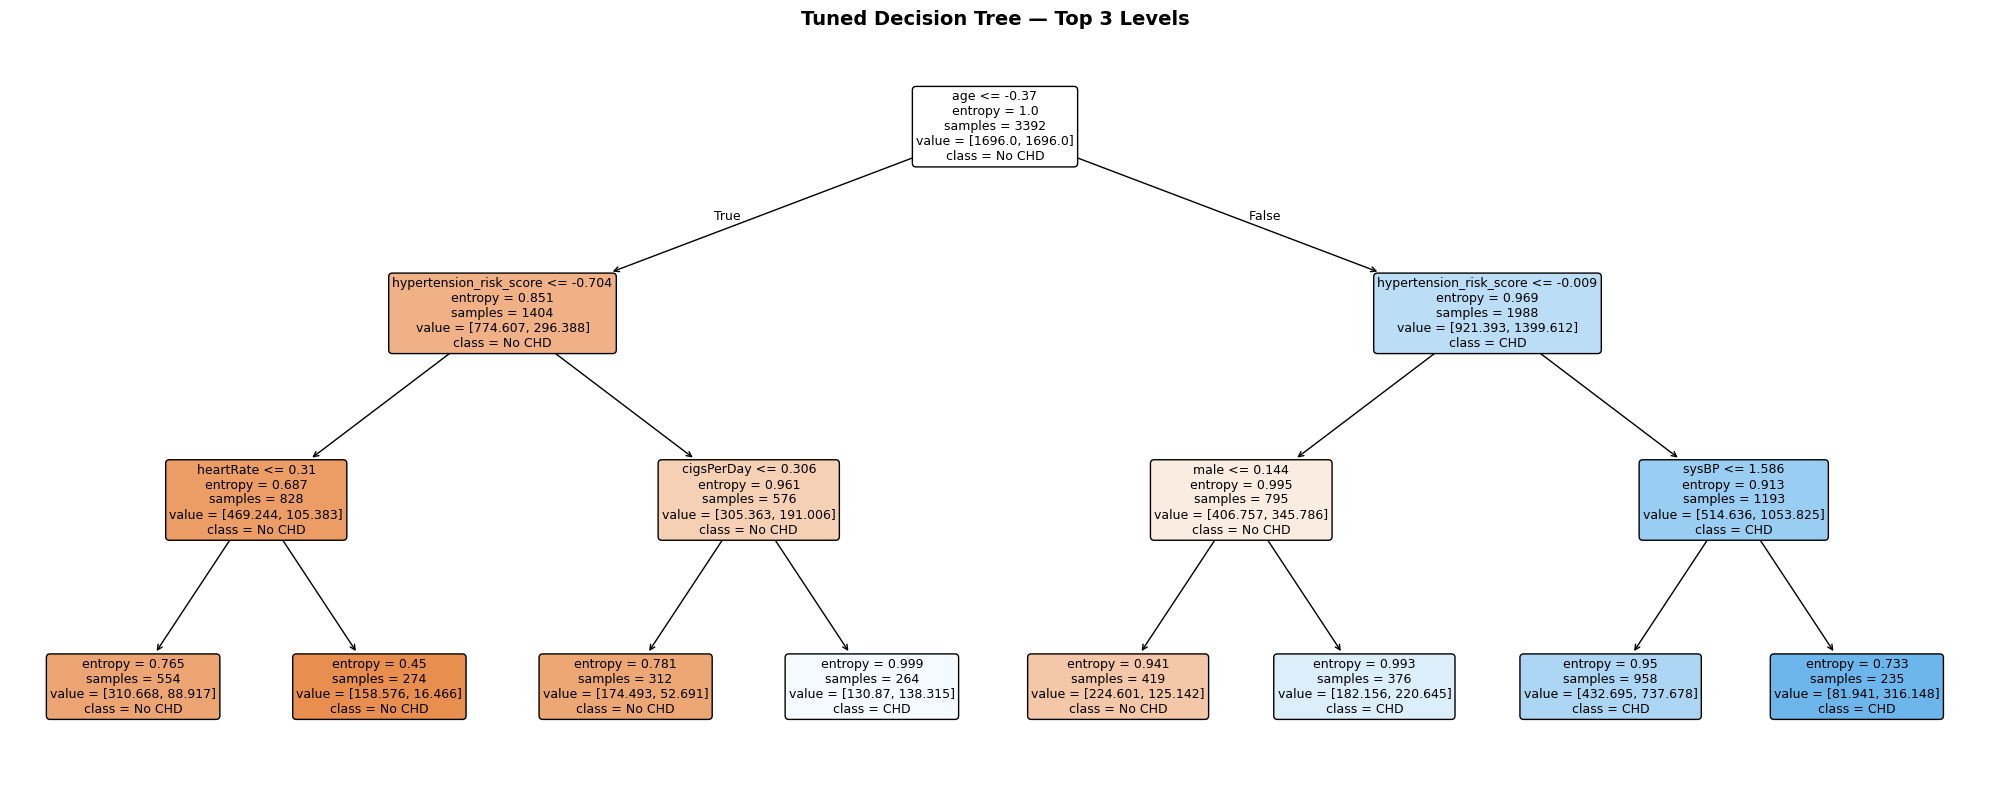

In [33]:
# Show the top 3 levels of the tuned tree
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    dt_tuned,
    max_depth=3,
    feature_names=feature_cols,
    class_names=['No CHD', 'CHD'],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax
)
ax.set_title('Tuned Decision Tree — Top 3 Levels', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Visualizations/1_dt_tree_visualization.png', dpi=150, bbox_inches='tight')
plt.show()